# LAB 7: Deep Learning
## Part 2 — Practice Exercise: A Real Pipeline, End to End

In Part 1 you watched `Dataset` and `DataLoader` work on 10 synthetic points. **Now you build the whole thing yourself**, on **Fashion-MNIST**: 70,000 greyscale images of clothing, 28×28 pixels each, sorted into 10 garment classes.

The focus of this exercise is the **data plumbing** — writing a `Dataset`, wiring a `DataLoader`, and getting every shape and dtype right. The model itself is deliberately the simplest thing that works.

### How this notebook works

- Cells marked **`TODO`** are yours to complete. Look for `# TODO:` and `...` placeholders.
- Every TODO is followed by a **self-check cell**. Run it — it tells you whether your answer is right and, when it is wrong, *why*.
- Each task has a **Hint** you can expand. Try without it first.
- Cells marked **`GIVEN`** are complete. Read them, run them, do not change them.
- **Runs in Google Colab as-is** — the data downloads itself, nothing to upload, no `pip install` needed.

### The pipeline you are building

```
784-pixel vectors -> official 60k/10k split -> normalise (stats from TRAIN only)
        -> tensors (float32 features, LONG labels) -> CustomDataset
        -> DataLoader(batch_size=32) -> Linear(784, 10) -> train loop -> argmax -> per-class accuracy
```

### Four things that will not raise an error

These run happily and give you a wrong answer or a wrong impression. They are the point of the exercise.

1. **Normalising with statistics from the whole dataset** → test information leaks into training → your accuracy is flattering and false.
2. **Applying `softmax` in `forward`** → `CrossEntropyLoss` applies its own log-softmax internally, so you squash the signal twice and training crawls. It expects **raw logits**.
3. **`argmax` without `dim=1`** → you get one number for the whole batch instead of one prediction per sample.
4. **Reporting overall accuracy only** → you will finish this notebook at about 81%, and one of the ten classes will be right barely a third of the time. TODO 10 makes you find it.

Work carefully. Nothing will shout at you.

---
## 0. Setup — `GIVEN`

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print('torch', torch.__version__, '| ready')

torch 2.12.1 | ready


### Load Fashion-MNIST — `GIVEN`

70,000 images, each flattened to a 784-element vector of pixel values in 0–255. Labels are the integers 0–9.


In [2]:
CACHE = 'fashion_mnist.npz'

def load_fashion_mnist():
    # 1. local cache - instant on re-runs
    if os.path.exists(CACHE):
        z = np.load(CACHE)
        return z['X'], z['y'], 'local cache'

    # 2. torchvision - the official source, and the fastest
    try:
        from torchvision import datasets
        tr = datasets.FashionMNIST('data', train=True,  download=True)
        te = datasets.FashionMNIST('data', train=False, download=True)
        feats = np.concatenate([tr.data.numpy().reshape(-1, 784),
                                te.data.numpy().reshape(-1, 784)])
        labs  = np.concatenate([tr.targets.numpy(), te.targets.numpy()])
        return feats, labs, 'torchvision'
    except Exception as e:
        print(f'  torchvision unavailable ({type(e).__name__}) - falling back to OpenML.')

    # 3. OpenML via scikit-learn
    from sklearn.datasets import fetch_openml
    feats, labs = fetch_openml('Fashion-MNIST', version=1, as_frame=False, return_X_y=True)
    return feats, labs, 'OpenML'


X, y, source = load_fashion_mnist()
X = X.astype(np.float32)
y = y.astype(np.int64)

if not os.path.exists(CACHE):
    np.savez_compressed(CACHE, X=X, y=y)
    print(f'Cached to {CACHE} - later runs in this session are instant.')

print(f'Loaded from: {source}')
print('X:', X.shape, X.dtype, '| pixel range', X.min(), '-', X.max())
print('y:', y.shape, y.dtype, '| classes', np.unique(y))

Loaded from: local cache
X: (70000, 784) float32 | pixel range 0.0 - 255.0
y: (70000,) int64 | classes [0 1 2 3 4 5 6 7 8 9]


### See what you are classifying — `GIVEN`

Each row of `X` is a flattened image. Reshape one to 28×28 and it becomes a picture again — that reshape is the whole difference between "a vector of 784 numbers" and "a photograph of a boot".

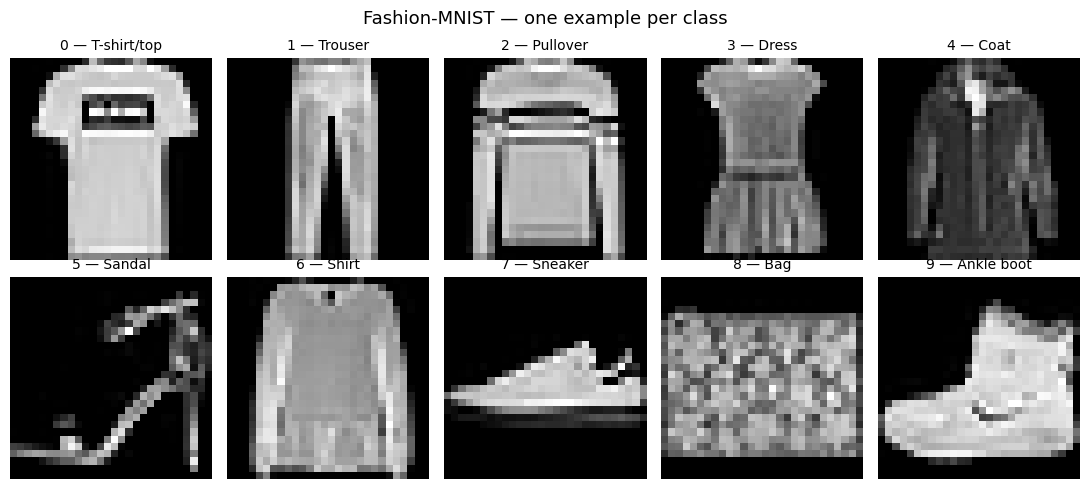

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for c, ax in enumerate(axes.flat):
    first = np.argmax(y == c)                 # first example of class c
    ax.imshow(X[first].reshape(28, 28), cmap='gray')
    ax.set_title(f'{c} — {CLASS_NAMES[c]}', fontsize=10)
    ax.axis('off')
plt.suptitle('Fashion-MNIST — one example per class', fontsize=13)
plt.tight_layout()
plt.show()

---
## TODO 1 — Look at the data before you model it

Answer four questions about the raw arrays.

<details>
<summary><b>Hint</b></summary>

- `X.shape` is `(rows, columns)`. Each row is one image; each column is one pixel.
- `len(np.unique(y))` counts the distinct labels.
- `np.bincount(y)` gives the count of each label as an array — check whether the classes are balanced before you decide accuracy is a fair metric.
</details>

In [ ]:
# TODO: fill in each value from `X` and `y`.

n_images     = ...   # how many images in total?
n_pixels     = ...   # how many pixels per image?
n_classes    = ...   # how many distinct garment classes?
counts       = ...   # count of each class, as an array of length 10

print(f'{n_images} images, {n_pixels} pixels each, {n_classes} classes')
print('per-class counts:', counts)

In [ ]:
# --- self-check 1 ---
assert n_images == 70000, f'n_images should be 70000, got {n_images}'
assert n_pixels == 784,   f'n_pixels should be 784 (28 x 28 = 784), got {n_pixels}'
assert n_classes == 10,   f'n_classes should be 10, got {n_classes}'
assert list(counts) == [7000] * 10, f'each class should have 7000 images, got {list(counts)}'

print('PASS - and note the balance: exactly 7000 of each class.')
print('       Perfectly balanced, so overall accuracy is not misleading by class FREQUENCY.')
print('       It can still hide a class the model simply cannot do. TODO 10 finds it.')

---
## TODO 2 — Split, then normalise

**Order matters and this is where the first silent bug lives.**

Fashion-MNIST ships with an official split: the **first 60,000** rows are the training set and the **last 10,000** are the test set. Everyone uses the same division, which is what makes published numbers comparable.

Two steps:
1. **Split** by slicing — no `train_test_split` needed, the boundary is fixed at 60,000.
2. **Compute normalisation statistics from the training set only**, then apply them to both. Pixel values run 0–255; the network trains far better on values centred near zero.

<details>
<summary><b>Hint</b></summary>

```python
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

pixel_mean = X_train.mean()     # ONE number, over the training images only
pixel_std  = X_train.std()
```

**Why not compute the mean over all 70,000?** Because the test set's statistics would then be baked into the numbers the model trains on. It is a small leak here, but it is the same mistake that inflates results badly on smaller datasets — and it never announces itself.

Do **not** apply the normalisation yet. In TODO 4 you will apply it inside `__getitem__`, which is where per-sample transformations belong.
</details>

In [ ]:
# TODO: split at the official boundary, then compute train-only statistics.

# 1. Split (first 60000 = train, last 10000 = test)
X_train, X_test = ...
y_train, y_test = ...

# 2. Normalisation statistics - from the TRAINING set only
pixel_mean = ...
pixel_std  = ...

print('X_train', X_train.shape, '| X_test', X_test.shape)
print(f'train pixel mean {pixel_mean:.4f}, std {pixel_std:.4f}')

In [ ]:
# --- self-check 2 ---
assert X_train.shape == (60000, 784), f'X_train should be (60000, 784), got {X_train.shape}'
assert X_test.shape  == (10000, 784), f'X_test should be (10000, 784), got {X_test.shape}'
assert y_train.shape == (60000,) and y_test.shape == (10000,), 'label arrays have the wrong shape'

assert abs(pixel_mean - 72.94) < 0.5, (
    f'pixel_mean is {pixel_mean:.4f}, expected about 72.94. '
    'Did you compute it over the TRAINING set only?')
assert abs(pixel_std - 90.02) < 0.5, f'pixel_std is {pixel_std:.4f}, expected about 90.02'

# If the statistics came from all 70000 rows they differ slightly - catch that.
full_mean = X.mean()
assert abs(pixel_mean - full_mean) > 1e-6, (
    'pixel_mean equals the mean of the WHOLE dataset, so you computed it before splitting. '
    'That leaks test statistics into training - use X_train only.')

print('PASS - split first, statistics from train only. No leakage.')
print(f'  train mean {pixel_mean:.4f}  vs  whole-dataset mean {full_mean:.4f}  <- deliberately different')

---
## TODO 3 — Convert to tensors

NumPy arrays go in, PyTorch tensors come out. **The dtypes are not interchangeable, and they differ between features and labels.**

- Features → **`float32`**. Networks compute in floats.
- Labels → **`long`** (64-bit integer), **not** float. `CrossEntropyLoss` expects class *indices*, and it raises if you hand it floats.

> This is the opposite of the binary case. `BCELoss` wants float targets; `CrossEntropyLoss` wants long ones. The loss function dictates the label dtype.

<details>
<summary><b>Hint</b></summary>

```python
X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.astype(np.int64))
```
`torch.from_numpy` will not cast for you — set the NumPy dtype first. `np.int64` becomes `torch.long`.

Leave the pixel values as raw 0–255 here. Normalisation happens in TODO 4.
</details>

In [ ]:
# TODO: convert all four arrays to tensors with the correct dtypes.

X_train_tensor = ...   # float32
X_test_tensor  = ...   # float32
y_train_tensor = ...   # long  <- class indices, not floats
y_test_tensor  = ...   # long

print('X_train_tensor', X_train_tensor.shape, X_train_tensor.dtype)
print('y_train_tensor', y_train_tensor.shape, y_train_tensor.dtype)

In [ ]:
# --- self-check 3 ---
for name, t, shape, dt in [('X_train_tensor', X_train_tensor, (60000, 784), torch.float32),
                           ('X_test_tensor',  X_test_tensor,  (10000, 784), torch.float32),
                           ('y_train_tensor', y_train_tensor, (60000,),     torch.long),
                           ('y_test_tensor',  y_test_tensor,  (10000,),     torch.long)]:
    assert isinstance(t, torch.Tensor), f'{name} is not a tensor'
    assert tuple(t.shape) == shape, f'{name} should be {shape}, got {tuple(t.shape)}'
    assert t.dtype == dt, (
        f'{name} should be {dt}, got {t.dtype}. '
        'Features are float32; labels are long because CrossEntropyLoss takes class indices.')

assert X_train_tensor.max() > 1.5, (
    'X_train_tensor looks already normalised. Leave the raw 0-255 values here - '
    'the normalisation belongs inside __getitem__ in TODO 4.')

print('PASS - float32 features, long labels, pixels still raw 0-255.')
print(f'  y_train_tensor[:8] = {y_train_tensor[:8].tolist()}  <- class indices, not one-hot')

---
## TODO 4 — Write the `Dataset`

The core of the exercise. Three methods, no more — **and this time `__getitem__` does real work.**

| Method | Returns |
|---|---|
| `__init__(self, features, labels, mean, std)` | nothing — stores what it needs |
| `__len__(self)` | an `int`: the number of samples |
| `__getitem__(self, index)` | **one** `(normalised_features, label)` tuple |

Normalising inside `__getitem__` is not a stylistic choice. It means the transform runs **lazily, per sample**, only on the images in the current batch — which is exactly what lets this pattern scale to datasets far too large to normalise up front, and what lets you add random augmentation later.

<details>
<summary><b>Hint</b></summary>

- `__len__` can read `self.features.shape[0]`.
- `__getitem__` fetches one row, normalises it, and returns it with its label:

```python
image = self.features[index]
image = (image - self.mean) / self.std
return image, self.labels[index]
```

- **The mistake to avoid:** returning a slice like `self.features[index:index+2]`. `__getitem__` returns *one* sample. The batch dimension is added later by the loader; add it here too and it gets created twice.
</details>

In [ ]:
class CustomDataset(Dataset):

    def __init__(self, features, labels, mean, std):
        # TODO: store the tensors and the two normalisation statistics on self
        ...

    def __len__(self):
        # TODO: return the number of samples as an int
        ...

    def __getitem__(self, index):
        # TODO: fetch ONE image, normalise it with (value - mean) / std,
        #       and return it together with its label
        ...


train_dataset = CustomDataset(X_train_tensor, y_train_tensor, pixel_mean, pixel_std)
test_dataset  = CustomDataset(X_test_tensor,  y_test_tensor,  pixel_mean, pixel_std)

print('train_dataset:', len(train_dataset), 'samples')
img, lab = train_dataset[0]
print('one sample ->', img.shape, img.dtype, '| label', lab.item(), '=', CLASS_NAMES[lab])

In [ ]:
# --- self-check 4 ---
assert len(train_dataset) == 60000, f'len(train_dataset) should be 60000, got {len(train_dataset)}'
assert len(test_dataset)  == 10000, f'len(test_dataset) should be 10000, got {len(test_dataset)}'

item = train_dataset[0]
assert isinstance(item, tuple) and len(item) == 2, \
    f'__getitem__ should return a (features, label) tuple, got {type(item).__name__}'

f, l = item
assert tuple(f.shape) == (784,), (
    f'features for ONE sample should be shape (784,), got {tuple(f.shape)}. '
    'A leading dimension means you returned a batch, not a sample.')
assert l.ndim == 0, f'the label for one sample should be a scalar tensor, got shape {tuple(l.shape)}'
assert l.dtype == torch.long, f'the label should stay long, got {l.dtype}'

# the normalisation must actually be applied
assert f.abs().max() < 6, (
    'the returned image still looks like raw 0-255 pixels - is the normalisation applied '
    'inside __getitem__?')
allf = torch.stack([train_dataset[i][0] for i in range(2000)])
assert abs(allf.mean().item()) < 0.15, \
    f'normalised images should sit near mean 0, got {allf.mean().item():.3f}'

# __getitem__ must actually index, not ignore its argument
assert not torch.equal(train_dataset[0][0], train_dataset[1][0]), \
    'train_dataset[0] and train_dataset[1] are identical - is __getitem__ using `index`?'

print('PASS - one normalised sample per call, no batch dimension in sight.')
print(f'  raw pixel range was 0 to 255; this sample now runs '
      f'{f.min():.2f} to {f.max():.2f}')

---
## TODO 5 — Wrap in `DataLoader`s

Two loaders, and **three** settings differ between them.

- **train**: `batch_size=32`, shuffled.
- **test**: `batch_size=256`, **not** shuffled.

<details>
<summary><b>Hint</b></summary>

```python
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)
```

**Why shuffle train but not test?** Shuffling breaks the order-correlation between consecutive batches, so each gradient estimate points roughly where the full-dataset gradient points. At test time no gradients are computed and order cannot change the metric — a fixed order just makes results reproducible.

**Why a bigger batch for test?** No gradients means no autograd graph and far less memory per sample, so you can push more through at once. Evaluation is not an optimisation process; there is no reason to keep the batches small.
</details>

In [ ]:
# TODO: build both loaders.

train_loader = ...
test_loader  = ...

print('train_loader:', len(train_loader), 'batches of 32')
print('test_loader: ', len(test_loader), 'batches of 256')

xb, yb = next(iter(train_loader))
print('one train batch ->', xb.shape, yb.shape, yb.dtype)

In [ ]:
# --- self-check 5 ---
# 60000 / 32 = 1875 exactly; 10000 / 256 = 39.06 -> 40 batches, last one holds 16
assert len(train_loader) == 1875, (
    f'train_loader should have 1875 batches (60000/32), got {len(train_loader)}. '
    'Check batch_size, and leave drop_last at its default False.')
assert len(test_loader) == 40, (
    f'test_loader should have 40 batches (ceil(10000/256)), got {len(test_loader)}')

xb, yb = next(iter(train_loader))
assert tuple(xb.shape) == (32, 784), f'a batch of features should be (32, 784), got {tuple(xb.shape)}'
assert tuple(yb.shape) == (32,),     f'a batch of labels should be (32,), got {tuple(yb.shape)}'
assert yb.dtype == torch.long,       f'batch labels should be long, got {yb.dtype}'

a = [tuple(l.tolist()) for _, l in torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)][:3]
first  = [tuple(l.tolist()) for i, (_, l) in enumerate(train_loader) if i < 3]
second = [tuple(l.tolist()) for i, (_, l) in enumerate(train_loader) if i < 3]
assert first != second, 'two passes gave identical batches - is shuffle=True on the train loader?'

c = [tuple(l.tolist()) for i, (_, l) in enumerate(test_loader) if i < 3]
d = [tuple(l.tolist()) for i, (_, l) in enumerate(test_loader) if i < 3]
assert c == d, 'the test loader is shuffling - it should use shuffle=False'

print('PASS - 1875 train batches, 40 test batches (the last holds 16).')
print('  Train reshuffles every epoch; test order is fixed.')

---
## TODO 6 — Define the model

Multinomial logistic regression, written as an `nn.Module`. The general pattern is always the same: **layers in `__init__`, computation in `forward`**.

784 pixels in, **10 raw scores out** — one per class.

### The trap

Do **not** apply `softmax` (or `sigmoid`) in `forward`. `CrossEntropyLoss` applies `log_softmax` internally. Add your own and the signal is squashed twice: the loss still decreases, no error is raised, and the model learns far more slowly than it should. The layer returns **logits** — unbounded real numbers, positive and negative.

<details>
<summary><b>Hint</b></summary>

```python
self.linear = nn.Linear(num_features, num_classes)   # 784 -> 10
```
and in `forward`, just `return self.linear(features)`. That is the whole model.

Don't forget `super().__init__()` as the first line of `__init__` — without it PyTorch cannot register the layer, and `model.parameters()` comes back empty.
</details>

In [ ]:
class FashionClassifier(nn.Module):

    def __init__(self, num_features, num_classes):
        super().__init__()
        # TODO: one Linear layer, num_features -> num_classes
        ...

    def forward(self, features):
        # TODO: return the raw logits - NO softmax here
        ...


model = FashionClassifier(784, 10)
print(model)

In [ ]:
# --- self-check 6 ---
n_params = sum(p.numel() for p in model.parameters())
assert n_params > 0, (
    'model has no parameters - did you call super().__init__() before assigning the layer?')
assert n_params == 7850, f'expected 7850 parameters (784*10 weights + 10 biases), got {n_params}'

# probe with normalised inputs - the same thing the Dataset hands the model
probe_x = torch.stack([train_dataset[i][0] for i in range(4)])
probe = model(probe_x)
assert tuple(probe.shape) == (4, 10), (
    f'model output for 4 samples should be (4, 10) - one score per class - got {tuple(probe.shape)}')

# raw logits are unbounded; a softmax/sigmoid would confine them
assert not (probe.min() >= 0 and probe.max() <= 1), (
    'every output sits inside [0, 1], which means you applied softmax or sigmoid in forward(). '
    'CrossEntropyLoss applies log_softmax itself - return RAW logits.')
row = torch.softmax(probe[0], dim=0)

print('PASS - 7850 parameters, output shape (4, 10), raw unbounded logits.')
print(f'  logits for image 0: {[round(v, 2) for v in probe[0].tolist()]}')
print(f'  after softmax they would sum to {row.sum():.4f} - but the LOSS does that, not you.')

---
## TODO 7 — Loss and optimiser

- Loss: **`nn.CrossEntropyLoss()`** — the multi-class counterpart of binary cross-entropy. It takes raw logits of shape `[B, 10]` and integer labels of shape `[B]`, and applies `log_softmax` internally.
- Optimiser: **SGD** over `model.parameters()`, learning rate `0.1`.

<details>
<summary><b>Hint</b></summary>

```python
loss_function = nn.CrossEntropyLoss()
optimizer     = torch.optim.SGD(model.parameters(), lr=0.1)
```
The optimiser needs `model.parameters()` — not the model itself. That is how it knows which tensors to update.
</details>

In [ ]:
# TODO: define the loss function and the optimiser.

loss_function = ...
optimizer     = ...

print(loss_function)
print(optimizer)

In [ ]:
# --- self-check 7 ---
assert isinstance(loss_function, nn.CrossEntropyLoss), \
    'loss_function should be an nn.CrossEntropyLoss instance (not BCELoss - this is 10-class)'
assert isinstance(optimizer, torch.optim.SGD), 'optimizer should be torch.optim.SGD'
assert optimizer.param_groups[0]['lr'] == 0.1, \
    f"learning rate should be 0.1, got {optimizer.param_groups[0]['lr']}"
assert len(optimizer.param_groups[0]['params']) == 2, \
    'the optimiser should be tracking 2 tensors (weight and bias) - pass model.parameters()'

# An untrained 10-class model should sit near ln(10) = 2.303.
# Note this must be measured on NORMALISED inputs - the ones the Dataset produces.
# Feed it raw 0-255 pixels and the logits explode, giving a meaningless number.
xb, yb = next(iter(test_loader))
start = loss_function(model(xb), yb).item()
raw   = loss_function(model(X_test_tensor[:256]), y_test_tensor[:256]).item()

print(f'PASS - untrained loss on normalised input: {start:.4f}   (ln(10) = {np.log(10):.4f})')
print(f'       untrained loss on RAW 0-255 input : {raw:.1f}')
print()
print('  A fresh 10-class model guessing uniformly scores exactly ln(10), and yours is close.')
print('  The second number is what happens without normalisation: the logits explode and')
print('  the gradients with them. That is why TODO 4 normalises inside __getitem__.')

---
## TODO 8 — The training loop

**The heart of the exercise.** Two nested loops: epochs outside, batches inside. The inner body has five steps.

```
for epoch in range(epochs):
    for batch_features, batch_labels in train_loader:
        1. forward   -> logits
        2. loss      -> compare logits against integer labels
        3. zero_grad -> clear the previous gradients
        4. backward  -> compute new gradients
        5. step      -> update the weights
```

### The trap

**`zero_grad()` goes in the *inner* loop.** PyTorch *accumulates* gradients: `loss.backward()` **adds** to `.grad` rather than replacing it. Put `zero_grad()` in the outer loop and batch 2's update is driven by batches 1+2, batch 3's by 1+2+3, and so on. The effective learning rate grows through the epoch and training destabilises — with **no error raised**.

Note what you do *not* need here: no `.view(-1, 1)`. `CrossEntropyLoss` takes logits `[B, 10]` and labels `[B]` exactly as they come. The reshaping dance belongs to the binary case.

> 1875 batches × 10 epochs ≈ **20 seconds** on a laptop CPU.

<details>
<summary><b>Hint</b></summary>

```python
logits = model(batch_features)
loss   = loss_function(logits, batch_labels)
optimizer.zero_grad()
loss.backward()
optimizer.step()
```
Accumulate `loss.item()` into `epoch_loss`, then divide by `len(train_loader)` when printing. Printing the bare `loss.item()` reports only the **last batch**, which is noisy and not comparable between runs.
</details>

In [ ]:
import time

epochs = 10
loss_history = []
t0 = time.time()

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_features, batch_labels in train_loader:
        # TODO 1. forward pass -> logits
        logits = ...

        # TODO 2. loss (logits [B,10] against integer labels [B])
        loss = ...

        epoch_loss += loss.item()

        # TODO 3. clear the old gradients
        ...
        # TODO 4. backpropagate
        ...
        # TODO 5. update the weights
        ...

    avg = epoch_loss / len(train_loader)
    loss_history.append(avg)
    print(f'Epoch {epoch + 1:2d} | avg loss = {avg:.4f}  ({time.time() - t0:5.1f}s elapsed)')

In [ ]:
# --- self-check 8 ---
assert len(loss_history) == 10, 'loss_history should hold one average per epoch'
assert loss_history[-1] < loss_history[0], (
    f'loss did not decrease ({loss_history[0]:.4f} -> {loss_history[-1]:.4f}). '
    'Check that zero_grad/backward/step are all present and in the right order.')
assert loss_history[-1] < 0.95, (
    f'final loss {loss_history[-1]:.4f} is higher than expected (~0.75). '
    'Common causes: zero_grad() outside the batch loop, a softmax in forward(), '
    'or the learning rate not set to 0.1.')

print(f'PASS - loss fell {loss_history[0]:.4f} -> {loss_history[-1]:.4f} over 10 epochs.')
print(f'  {len(train_loader)} batches x 10 epochs = {len(train_loader) * 10:,} weight updates.')
print('  Full-batch training would have given you 10.')

### Optional — plot the loss curve

Not graded. But a loss curve tells you more in one glance than ten printed numbers.

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', ms=5)
plt.xlabel('Epoch'); plt.ylabel('Average cross-entropy loss')
plt.title('Training loss')
plt.grid(True, alpha=0.3)
plt.show()

---
## TODO 9 — Evaluate

Evaluation needs **two** guards, and they do different jobs:

- **`model.eval()`** — switches inference behaviour on: dropout stops dropping, batch-norm uses its running statistics instead of the current batch's. This model has neither layer, but make it a habit; the day you add dropout, forgetting it makes your test predictions random.
- **`torch.no_grad()`** — stops the autograd graph being built. Without it, every test batch allocates memory for a backward pass that never happens.

Then turn each row of 10 logits into a single predicted class with **`argmax`**.

### The trap

`logits.argmax()` with no arguments flattens the whole `[B, 10]` batch and returns **one** number — the position of the single largest value anywhere in the batch. You want `argmax(dim=1)`: the largest **per row**, giving `[B]` predictions. Nothing warns you.

<details>
<summary><b>Hint</b></summary>

```python
logits = model(batch_features)
preds  = logits.argmax(dim=1)        # shape [B], one class index per image
```
Collect predictions and labels across all batches, then compare once at the end. Averaging per-batch accuracies is subtly wrong when the last batch is smaller — it would weight those 16 images the same as a full 256.
</details>

In [ ]:
# TODO: complete the evaluation.

model.eval()                     # given: inference mode
all_preds, all_labels = [], []

with torch.no_grad():            # given: no autograd graph
    for batch_features, batch_labels in test_loader:
        # TODO: get logits, then the predicted class per image (shape [B])
        preds = ...

        all_preds.append(preds)
        all_labels.append(batch_labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# TODO: compute overall accuracy as a float
accuracy = ...

print(f'Test accuracy: {accuracy:.4f}  '
      f'({int((all_preds == all_labels).sum())}/{len(all_labels)} correct)')

In [ ]:
# --- self-check 9 ---
assert tuple(all_preds.shape) == (10000,), (
    f'all_preds should be shape (10000,), got {tuple(all_preds.shape)}. '
    'If it is much smaller you used argmax() without dim=1.')
assert set(all_preds.unique().tolist()) <= set(range(10)), \
    'predictions should be class indices 0-9'
assert 0.70 < accuracy < 0.90, (
    f'accuracy {accuracy:.4f} is outside the expected 0.70-0.90 range for a linear model. '
    'If it is near 0.10 the model is guessing; check TODO 8.')

print(f'PASS - test accuracy {accuracy:.4f}')
print('  Guessing at random would score 0.10, so the model has clearly learned something.')
print('  Now do not stop here. That single number is hiding a serious failure - TODO 10.')

---
## TODO 10 — Overall accuracy hides the truth

About 81% sounds respectable. It is also nearly useless as a description of this model, because it averages over ten classes that the model handles **very** differently.

Compute the accuracy **for each class separately**, and find what each class gets mistaken for.

<details>
<summary><b>Hint</b></summary>

For class `c`:
```python
mask      = (all_labels == c)                      # the images that really are class c
correct   = (all_preds[mask] == c).sum().item()    # how many did we get right
total     = mask.sum().item()                      # how many there were
```
For the most common confusion, look at the predictions for those images that were *not* `c`, and find the most frequent value — `torch.bincount(wrong, minlength=10).argmax()`.
</details>

In [ ]:
print(f'{"class":<14} {"accuracy":>9}   {"most often mistaken for":<20}')
print('-' * 50)

per_class = []

for c in range(10):
    # TODO: compute this class's accuracy and its most common wrong prediction
    mask        = ...                 # boolean tensor: which test images really are class c
    class_acc   = ...                 # fraction of those the model got right
    wrong_preds = all_preds[mask][all_preds[mask] != c]

    confused_with = torch.bincount(wrong_preds, minlength=10).argmax().item() \
                    if len(wrong_preds) else c

    per_class.append(class_acc)
    print(f'{CLASS_NAMES[c]:<14} {class_acc:>9.3f}   {CLASS_NAMES[confused_with]:<20}')

worst = int(np.argmin(per_class))
print()
print(f'Overall accuracy : {accuracy:.3f}')
print(f'Worst class      : {CLASS_NAMES[worst]} at {per_class[worst]:.3f}')

In [ ]:
# --- self-check 10 ---
assert len(per_class) == 10, 'per_class should hold one accuracy per class'
assert all(0.0 <= a <= 1.0 for a in per_class), 'accuracies should be fractions between 0 and 1'

ref = [( (all_preds[all_labels == c] == c).float().mean().item() ) for c in range(10)]
assert all(abs(a - b) < 1e-6 for a, b in zip(per_class, ref)), \
    'your per-class accuracies do not match a direct recomputation - check the mask'

assert min(per_class) < 0.65, (
    'no class scored below 0.65, which is unexpected here - check your mask logic')

print('PASS - per-class accuracies verified.')
print()
print(f'  Overall            {accuracy:.3f}')
print(f'  Best  ({CLASS_NAMES[int(np.argmax(per_class))]:<11}) {max(per_class):.3f}')
print(f'  Worst ({CLASS_NAMES[int(np.argmin(per_class))]:<11}) {min(per_class):.3f}')
print()
print(f'  The spread is {max(per_class) - min(per_class):.3f}. One number could not have told you that.')

### Look at what it confuses — `GIVEN`

The confusions are not random. Run this and read the diagonal against the off-diagonal.

In [ ]:
cm = torch.zeros(10, 10, dtype=torch.int32)
for t, p in zip(all_labels.tolist(), all_preds.tolist()):
    cm[t][p] += 1

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion matrix — where the model goes wrong')
for i in range(10):
    for j in range(10):
        v = cm[i][j].item()
        if v > 0:
            ax.text(j, i, v, ha='center', va='center', fontsize=7.5,
                    color='white' if v > cm.max().item() * 0.5 else '#333')
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

### Write your answer

**Question 1.** Which classes does the model confuse most, and why does that make sense? Look at the sample images at the top of this notebook before answering.

*Your answer:*

> _(replace this line)_

**Question 2.** You are asked to report a single number describing this model to a non-technical stakeholder. Is overall accuracy an honest choice here? If not, what would you report instead?

*Your answer:*

> _(replace this line)_

---
## Stretch goals

For early finishers. Nothing here is checked automatically.

**1. Reproduce the leakage bug.** Re-run TODO 2 computing `pixel_mean` and `pixel_std` over the whole 70,000 rows instead of the training 60,000. Retrain and re-evaluate. How much does accuracy move? On this dataset the leak is small — explain why, and say which kind of dataset would make it large.

**2. Turn the `batch_size` knob.** Retrain with `batch_size=1` and with `batch_size=2048`. Compare wall-clock time per epoch, updates per epoch, and the shape of the loss curve. Which converges in fewer *epochs*? Which converges in less *time*? They are not the same question.

**3. Add a hidden layer.**
```python
nn.Linear(784, 128) -> nn.ReLU() -> nn.Linear(128, 10)
```
Does the Shirt class improve? A linear model cannot separate Shirt from T-shirt; can one hidden layer?

**4. Set `num_workers=2` on the train loader.** Time one epoch before and after. On this in-memory dataset, does it help? Explain the result — the answer is in Section 9 of the notes.

**5. Move the normalisation out of `__getitem__`** and apply it once to the whole array in TODO 3 instead. The accuracy will be identical. Now say what you have given up, and at what dataset size it would start to matter.

**6. Break `__getitem__` deliberately.** Make it return two samples instead of one. Print the shape of a batch. Note that nothing raises an exception.

---
## Wrap-up

You built this, end to end:

```
784-pixel vectors -> official 60k/10k split -> normalisation stats from TRAIN only
        -> float32 features + long labels -> CustomDataset (normalises in __getitem__)
        -> DataLoader(batch_size=32, shuffle=True) -> Linear(784, 10)
        -> train loop -> argmax -> per-class accuracy
```

**The transferable part:** the `CustomDataset` you wrote here is structurally identical to the one from the 10-sample toy demo. Same three methods, same contract. Nothing about it knew or cared that the data went from 10 synthetic points to 60,000 photographs of clothing.

That is the whole payoff of the abstraction. Swap in MRI scans or a text corpus tomorrow and you rewrite **only** `__init__` and `__getitem__` — the `DataLoader` call, the model, the training loop and the evaluation loop are untouched.

### Final questions

1. Which two `CustomDataset` methods did the `DataLoader` call, and what does each return?
2. Your train loader had exactly 1875 batches for 60,000 images at `batch_size=32`, but the test loader had 40 for 10,000 at `batch_size=256`. Why is one of those an exact division and the other not, and how many images were in the final test batch?
3. Why did the labels have to be `long` here when the breast-cancer version needed `float32`?
4. What goes wrong if you apply `softmax` inside `forward` and then use `CrossEntropyLoss`? Would you get an error?
5. `argmax()` and `argmax(dim=1)` both run without complaint on a `[256, 10]` tensor. What does each return, and which one did you need?
6. You switch this pipeline from flat 784-vectors to a folder of PNG files on disk. Which components have to change?